In [1]:
import numpy as np
import sympy as smp
import scipy as sp

from ipywidgets import interact, interactive, fixed
import ipywidgets as widgets
from ipywidgets import interactive, widgets, HBox, VBox

import math
from engineering_notation import EngNumber
import matplotlib.pyplot as plt
from matplotlib.widgets import Cursor
from matplotlib.pyplot import semilogx
from matplotlib import pyplot
%matplotlib inline

#logger = Logging.setup_logging()

import PySpice.Logging.Logging as Logging
from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

/home/bp/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


### Моделювання роботи діодного мосту 

interactive(children=(IntSlider(value=20, description='$R_{1}, [kOhm]$', max=50, min=1), IntSlider(value=45, d…

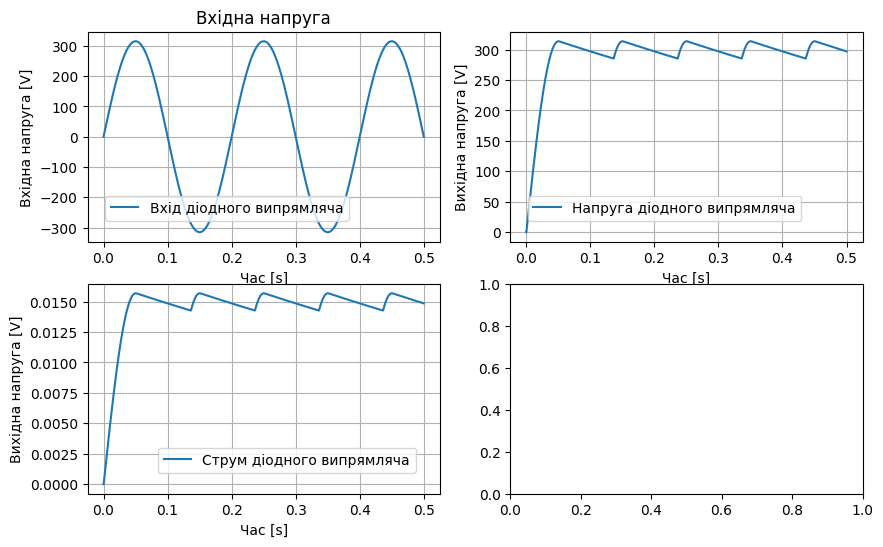

In [2]:
def g(R1_sb, C1_sb, F_sb):
    ## Circuit Netlist
    circuit = Circuit('Diode rectifier')
    circuit.include("1N4007.mod")

    # Define transient simulation step time and stop time
    steptime = 0.0001
    finaltime = 0.5

    circuit.SinusoidalVoltageSource('Vsin', 'in1', 'in2', offset=0, amplitude=315, frequency=F_sb)
    
    circuit.D('D1', 'in1',   'out_p', model='DI_1N4007')
    circuit.D('D2', 'in2',   'out_p', model='DI_1N4007')
    circuit.D('D3', 'out_n', 'in1',   model='DI_1N4007')
    circuit.D('D4', 'out_n', 'in2',   model='DI_1N4007')

    circuit.R('R1', 'out_p', 'out_n', R1_sb@u_kΩ)
    circuit.R('R2', 'out_n', circuit.gnd, 0@u_kΩ)

    circuit.C('C1', 'out_p', 'out_n', C1_sb@u_uF)
    
    ## Simulation: Transient Analysis
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)
    
    # PLOTTING COMMANDS
    figure, ((axe1, axe2), (axe3, axe4)) = plt.subplots(2, 2, figsize=(10, 6))
        
    axe1.set_title('Вхідна напруга')
    axe1.set_xlabel('Час [s]')
    axe1.set_ylabel('Вхідна напруга [V]')
    axe1.grid()
    plot(analysis['in1']-analysis['in2'], axis=axe1)
    #axe1.set_ylim(-9, 9)  # Adjust limit for better visualization
    axe1.legend(('Вхід діодного випрямляча', 'Вхід'), loc=(.05, .1))
    cursor = Cursor(axe1, useblit=True, color='red', linewidth=1)
    
    axe2.set_title('')
    axe2.set_xlabel('Час [s]')
    axe2.set_ylabel('Вихідна напруга [V]')
    axe2.grid()
    plot(analysis['out_p']-analysis['out_n'], axis=axe2)
    #axe2.set_ylim(0, 9)  # Adjust limit for better visualization
    axe2.legend(('Напруга діодного випрямляча', 'Вихід'), loc=(.05, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)

    axe3.set_title('')
    axe3.set_xlabel('Час [s]')
    axe3.set_ylabel('Вихідна напруга [V]')
    axe3.grid()
    plot((analysis['out_p']-analysis['out_n'])/(R1_sb*1000), axis=axe3)
    #axe2.set_ylim(0, 9)  # Adjust limit for better visualization
    axe3.legend(('Cтрум діодного випрямляча', 'Вихід'), loc=(.2, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)
    
w = interactive(g,
                R1_sb=widgets.IntSlider(min=1, max=50, step=1, value=20, description ='$R_{1}, [kOhm]$'),
                C1_sb=widgets.IntSlider(min=1, max=1000, step=1, value=45, description ='$C_{1}, [nF]$'),
                F_sb=widgets.IntSlider(min=1, max=20, step=1, value=5, description ='$F_{sw}, [Hz]$')
               )
display(w)

NameError: name 'analysis' is not defined

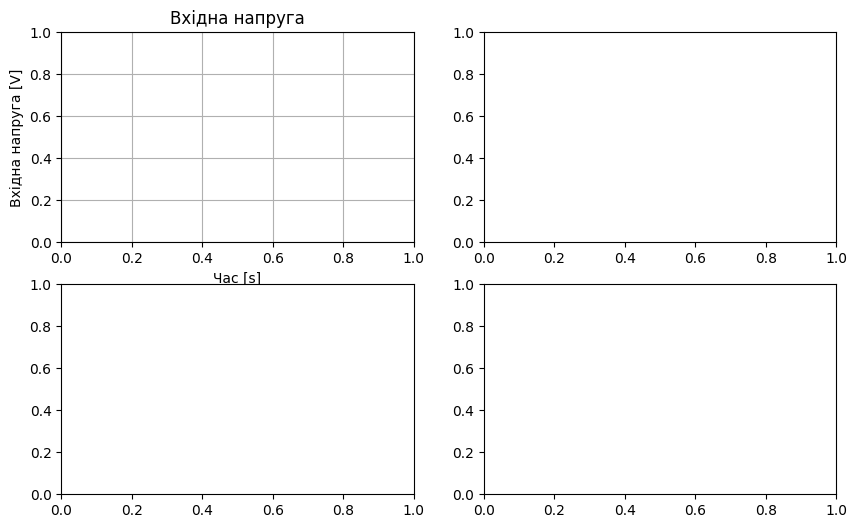

In [3]:
    # PLOTTING COMMANDS
    figure, ((axe1, axe2), (axe3, axe4)) = plt.subplots(2, 2, figsize=(10, 6))
        
    axe1.set_title('Вхідна напруга')
    axe1.set_xlabel('Час [s]')
    axe1.set_ylabel('Вхідна напруга [V]')
    axe1.grid()
    plot(analysis['in1']-analysis['in2'], axis=axe1)
    #axe1.set_ylim(-9, 9)  # Adjust limit for better visualization
    axe1.legend(('Вхід діодного випрямляча', 'Вхід'), loc=(.05, .1))
    cursor = Cursor(axe1, useblit=True, color='red', linewidth=1)
    
    axe2.set_title('')
    axe2.set_xlabel('Час [s]')
    axe2.set_ylabel('Вихідна напруга [V]')
    axe2.grid()
    plot(analysis['out_p']-analysis['out_n'], axis=axe2)
    #axe2.set_ylim(0, 9)  # Adjust limit for better visualization
    axe2.legend(('Напруга діодного випрямляча', 'Вихід'), loc=(.05, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)

    axe3.set_title('')
    axe3.set_xlabel('Час [s]')
    axe3.set_ylabel('Вихідна напруга [V]')
    axe3.grid()
    plot((analysis['out_p']-analysis['out_n'])/(R1_sb*1000), axis=axe3)
    #axe2.set_ylim(0, 9)  # Adjust limit for better visualization
    axe3.legend(('Cтрум діодного випрямляча', 'Вихід'), loc=(.2, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)

In [4]:
def g(R1_sb, C1_sb, F_sb):
    ## Circuit Netlist
    circuit = Circuit('Diode rectifier')
    circuit.include("1N4007.mod")

    # Define transient simulation step time and stop time
    steptime = 0.0001
    finaltime = 0.5

    circuit.SinusoidalVoltageSource('Vsin', 'in1', 'in2', offset=0, amplitude=315, frequency=F_sb)
    
    circuit.D('D1', 'in1',   'out_p', model='DI_1N4007')
    circuit.D('D2', 'in2',   'out_p', model='DI_1N4007')
    circuit.D('D3', 'out_n', 'in1',   model='DI_1N4007')
    circuit.D('D4', 'out_n', 'in2',   model='DI_1N4007')

    circuit.R('R1', 'out_p', 'out_n', R1_sb@u_kΩ)
    circuit.R('R2', 'out_n', circuit.gnd, 0@u_kΩ)

    circuit.C('C1', 'out_p', 'out_n', C1_sb@u_uF)
    
    ## Simulation: Transient Analysis
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.transient(step_time=steptime, end_time=finaltime)
    
    # PLOTTING COMMANDS
    figure, ((axe1, axe2), (axe3, axe4)) = plt.subplots(2, 2, figsize=(10, 6))
        
    axe1.set_title('Вхідна напруга')
    axe1.set_xlabel('Час [s]')
    axe1.set_ylabel('Вхідна напруга [V]')
    axe1.grid()
    plot(analysis['in1']-analysis['in2'], axis=axe1)
    #axe1.set_ylim(-9, 9)  # Adjust limit for better visualization
    axe1.legend(('Вхід діодного випрямляча', 'Вхід'), loc=(.05, .1))
    cursor = Cursor(axe1, useblit=True, color='red', linewidth=1)
    
    axe2.set_title('')
    axe2.set_xlabel('Час [s]')
    axe2.set_ylabel('Вихідна напруга [V]')
    axe2.grid()
    plot(analysis['out_p']-analysis['out_n'], axis=axe2)
    #axe2.set_ylim(0, 9)  # Adjust limit for better visualization
    axe2.legend(('Напруга діодного випрямляча', 'Вихід'), loc=(.05, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)

    axe3.set_title('')
    axe3.set_xlabel('Час [s]')
    axe3.set_ylabel('Вихідна напруга [V]')
    axe3.grid()
    plot((analysis['out_p']-analysis['out_n'])/(R1_sb*1000), axis=axe3)
    #axe2.set_ylim(0, 9)  # Adjust limit for better visualization
    axe3.legend(('Cтрум діодного випрямляча', 'Вихід'), loc=(.2, .1))
    cursor = Cursor(axe2, useblit=True, color='red', linewidth=1)
    
w = interactive(g,
                {'manual': True},
                R1_sb=widgets.IntSlider(min=1, max=50, step=1, value=20, description ='$R_{1}, [kOhm]$'),
                C1_sb=widgets.IntSlider(min=1, max=1000, step=1, value=45, description ='$C_{1}, [nF]$'),
                F_sb=widgets.IntSlider(min=1, max=20, step=1, value=5, description ='$F_{sw}, [Hz]$')
               )
display(w)

interactive(children=(IntSlider(value=20, description='$R_{1}, [kOhm]$', max=50, min=1), IntSlider(value=45, d…

## Типи діодів
- Diode / Діод (випрямлення напруги)
- Zener diode / Стабілітрон (Для стабілізації напруги)
- Schotthy diode / Діод Шоткі (Для ВЧ застосувань)
- Tunnel Diode / Тунельний діод
- Light Emitting Diode / Світлодіод
- Photodiode / Фотодіод
- Laser Diode / Лазер
- Varactor Diode / Варикап (В приймальних контурах приймачів)

In [5]:
def g(d_sb, a_sb, b_sb):
    d, a, b, t = smp.symbols("d a b t")
    expr = smp.Heaviside(t-d,1)*(a + b * t)
    t_values = np.arange(0, 10, 0.1)
    # Use list comprehension to substitute each x value into the vector expression
    result_vector = [expr.subs([(d, d_sb), (a, a_sb), (b, b_sb), (t, tim)]) for tim in t_values]
    
    # Create a scatter plot
    plt.plot(t_values, result_vector)
    plt.xlim(-1, 7)  # Adjust limit for better visualization
    plt.ylim(-1, 10)  # Adjust limit for better visualization
    plt.xlabel('t')
    plt.ylabel('f(t)')
    plt.title('Рівняння лінії: $H(t-d)\cdot(a+b \cdot t)$')
    plt.show()

w = interactive(g, 
                d_sb=widgets.FloatSlider(min=0.2, max=3, step=0.1, value=1.6, description = 'Параметр: d'), 
                a_sb=widgets.FloatSlider(min=-10, max=10, step=0.1, value=-6, description = 'Параметр: a'), 
                b_sb=widgets.FloatSlider(min=0, max=10, step=0.1, value=4, description ='Параметр: b')
               )
display(w)

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_48907/405676002.py:14: SyntaxWarning: invalid escape sequence '\c'
  plt.title('Рівняння лінії: $H(t-d)\cdot(a+b \cdot t)$')


interactive(children=(FloatSlider(value=1.6, description='Параметр: d', max=3.0, min=0.2), FloatSlider(value=-…

In [6]:
def g(R1_sb, C1_sb, F_sb):
    ## Circuit Netlist
    circuit = Circuit('Diode rectifier')
    #circuit.include("DIODE2.LIB")

    # Define transient simulation step time and stop time
    steptime = 0.0001
    finaltime = 0.5

    Vin1 = circuit.V('vinp', 'Vinput', circuit.gnd, -1@u_V)
    circuit.R('R1', 'Voutput', 'Vinput', R1_sb@u_kΩ)
    #circuit.D('D1', 'Voutput', circuit.gnd, model='ZN4057')
    circuit.R('R2', 'Voutput', circuit.gnd, 10@u_kΩ)

    
    ## Simulation: Transient Analysis
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc()
    
    
    
w = interactive(g,
                {'manual': True},
                R1_sb=widgets.IntSlider(min=1, max=50, step=1, value=20, description ='$R_{1}, [kOhm]$'),
                C1_sb=widgets.IntSlider(min=1, max=1000, step=1, value=45, description ='$C_{1}, [nF]$'),
                F_sb=widgets.IntSlider(min=1, max=20, step=1, value=5, description ='$F_{sw}, [Hz]$')
               )
display(w)

interactive(children=(IntSlider(value=20, description='$R_{1}, [kOhm]$', max=50, min=1), IntSlider(value=45, d…

In [7]:
import numpy as np
import matplotlib.pyplot as plt


import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()


from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *


circuit.include("DIODE4.LIB")


figure, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 6))

circuit = Circuit('Transistor')

Vbase = circuit.V('base', 1, circuit.gnd, 1@u_V)
circuit.R('base1', 1, 'base', 1@u_kΩ)
circuit.R('collector', 'base', circuit.gnd, 1@u_kΩ)

circuit.D('D1', 'base', circuit.gnd, model='Z02BZ2_2')




simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.dc(Vbase=slice(0, 3, .01))

ax1.plot(analysis.base, u_mA(-analysis.Vbase)) # Fixme: I_Vbase
ax1.axvline(x=.65, color='red')
ax1.legend(('Base-Emitter Diode curve',), loc=(.1,.8))
ax1.grid()
ax1.set_xlabel('Vbe [V]')
ax1.set_ylabel('Ib [mA]')



plt.tight_layout()
plt.show()

NameError: name 'circuit' is not defined

In [10]:
def g(R_1_sb, R_2_sb, R_c_sb, R_e_sb, R_l_sb, C_1_sb, C_2_sb):
    circuit = Circuit('Transistor')
    circuit.V('power', 5, circuit.gnd, 15@u_V)
    source = circuit.SinusoidalVoltageSource('in', 'in', circuit.gnd, amplitude=.5@u_V, frequency=1@u_kHz)
    circuit.C(1, 'inp', 2, C_1_sb@u_uF)
    circuit.R(1, 5, 2, R_1_sb@u_kΩ)
    circuit.R(2, 2, 0, R_2_sb@u_kΩ)
    circuit.R('C', 5, 4, R_c_sb@u_kΩ)
    circuit.BJT(1, 4, 2, 3, model='bjt') # Q is mapped to BJT !
    circuit.model('bjt', 'npn', bf=80, cjc=pico(5), rb=100)
    circuit.R('E', 3, 0, R_e_sb@u_kΩ)
    circuit.C(2, 4, 'out', C_2_sb@u_uF)
    circuit.R('Load', 'out', 0, R_l_sb@u_MΩ)

    # .ac dec 5 10m 1G
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.transient(step_time=source.period/200, end_time=source.period*4)
    
    figure, axe = plt.subplots(figsize=(10, 6))
    plt.title('')
    plt.xlabel('Time [s]')
    plt.ylabel('Voltage [V]')
    plt.grid()
    plot(analysis['inp'], axis=axe)
    plot(analysis.out, axis=axe)
    plt.title('Підсилювач за схемою зі спільним еммітером')
    plt.xlabel('Час, [с]')
    plt.ylabel('Напруга, [В]')
    plt.legend(('Вхідний сигнал', 'Вихідний сигнал'), loc='best')

    plt.tight_layout()
    plt.show()

w = interactive(g,
                {'manual': True},
                R_1_sb=widgets.IntSlider(min=0, max=200, step=10, value=100, description = '$R_{1}, [k\Omega]$'), 
                R_2_sb=widgets.IntSlider(min=0, max=100, step=10, value=20, description = '$R_{2}, [k\Omega]$'), 
                R_c_sb=widgets.IntSlider(min=0, max=100, step=1, value=10, description = '$R_{c}, [k\Omega]$'), 
                R_e_sb=widgets.IntSlider(min=0, max=20, step=1, value=2, description = '$R_{e}, [k\Omega]$'), 
                R_l_sb=widgets.IntSlider(min=0, max=1000, step=10, value=1000, description = '$R_{l}, [k\Omega]$'), 
                C_1_sb=widgets.IntSlider(min=1, max=1000, step=10, value=10, description = '$C_{1},[mF]$'),
                C_2_sb=widgets.IntSlider(min=1, max=1000, step=10, value=10, description = '$C_{2},[mF]$'))
display(w)

<>:36: SyntaxWarning: invalid escape sequence '\O'
<>:37: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:39: SyntaxWarning: invalid escape sequence '\O'
<>:40: SyntaxWarning: invalid escape sequence '\O'
<>:36: SyntaxWarning: invalid escape sequence '\O'
<>:37: SyntaxWarning: invalid escape sequence '\O'
<>:38: SyntaxWarning: invalid escape sequence '\O'
<>:39: SyntaxWarning: invalid escape sequence '\O'
<>:40: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_48907/603630929.py:36: SyntaxWarning: invalid escape sequence '\O'
  R_1_sb=widgets.IntSlider(min=0, max=200, step=10, value=100, description = '$R_{1}, [k\Omega]$'),
/tmp/ipykernel_48907/603630929.py:37: SyntaxWarning: invalid escape sequence '\O'
  R_2_sb=widgets.IntSlider(min=0, max=100, step=10, value=20, description = '$R_{2}, [k\Omega]$'),
/tmp/ipykernel_48907/603630929.py:38: SyntaxWarning: invalid escape sequence '\O'
  R_c_sb=widgets.IntSlider(min=0, max=100, st

interactive(children=(IntSlider(value=100, description='$R_{1}, [k\\Omega]$', max=200, step=10), IntSlider(val…

/home/bp/.local/lib/python3.12/site-packages/PySpice/Unit/Unit.py:1704: RuntimeWarning: divide by zero encountered in divide
  results = super(UnitValues, self).__array_ufunc__(ufunc, method, *args, **kwargs)


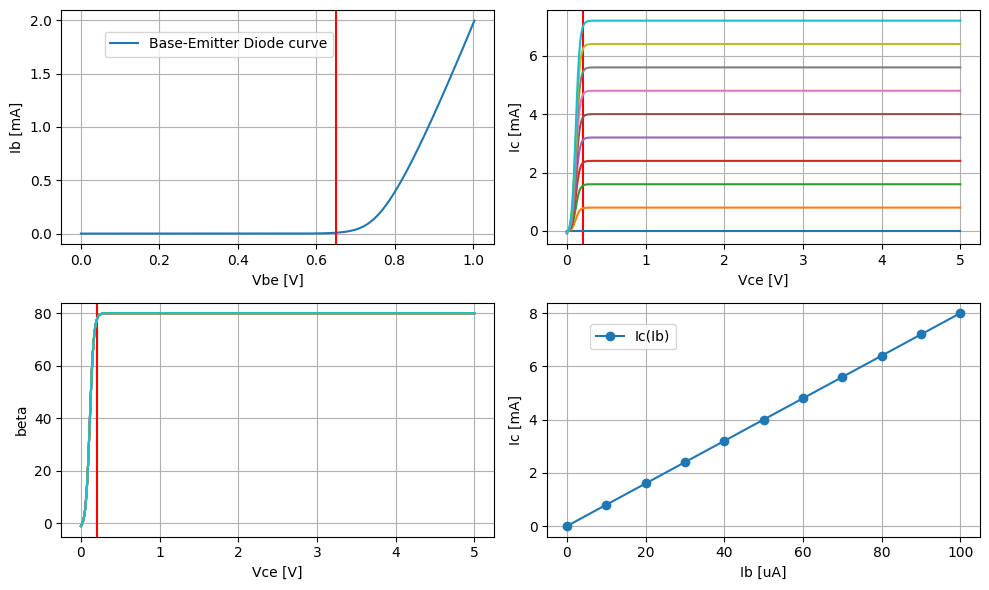

In [9]:
import numpy as np
import matplotlib.pyplot as plt


import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging()


from PySpice.Doc.ExampleTools import find_libraries
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *


libraries_path = find_libraries()
spice_library = SpiceLibrary(libraries_path)


figure, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 6))

circuit = Circuit('Transistor')

Vbase = circuit.V('base', '1', circuit.gnd, 1@u_V)
circuit.R('base', 1, 'base', 1@u_kΩ)
Vcollector = circuit.V('collector', '2', circuit.gnd, 0@u_V)
circuit.R('collector', 2, 'collector', 1@u_kΩ)
#circuit.include("BC556.lib")
#circuit.BJT(1, 'collector', 'base', circuit.gnd, model='BC556.lib')
circuit.BJT(1, 'collector', 'base', circuit.gnd, model='bjt') # Q is mapped to BJT !
circuit.model('bjt', 'npn', bf=80, cjc=pico(5), rb=100)

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.dc(Vbase=slice(0, 3, .01))

ax1.plot(analysis.base, u_mA(-analysis.Vbase)) # Fixme: I_Vbase
ax1.axvline(x=.65, color='red')
ax1.legend(('Base-Emitter Diode curve',), loc=(.1,.8))
ax1.grid()
ax1.set_xlabel('Vbe [V]')
ax1.set_ylabel('Ib [mA]')

circuit = Circuit('Transistor')
Ibase = circuit.I('base', circuit.gnd, 'base', 10@u_uA) # take care to the orientation
Vcollector = circuit.V('collector', 'collector', circuit.gnd, 5)
#circuit.include(spice_library['2n2222a'])
#circuit.BJT(1, 'collector', 'base', circuit.gnd, model='2n2222a')
circuit.BJT(1, 'collector', 'base', circuit.gnd, model='bjt') # Q is mapped to BJT !
circuit.model('bjt', 'npn', bf=80, cjc=pico(5), rb=100)

ax2.grid()
# ax2.legend(('Ic(Vce, Ib)',), loc=(.5,.5))
ax2.set_xlabel('Vce [V]')
ax2.set_ylabel('Ic [mA]')
ax2.axvline(x=.2, color='red')

ax3.grid()
# ax3.legend(('beta(Vce)',), loc=(.5,.5))
ax3.set_xlabel('Vce [V]')
ax3.set_ylabel('beta')
ax3.axvline(x=.2, color='red')

for base_current in np.arange(0, 100, 10):
    base_current = base_current@u_uA
    Ibase.dc_value = base_current
    simulator = circuit.simulator(temperature=25, nominal_temperature=25)
    analysis = simulator.dc(Vcollector=slice(0, 5, .01))
    # add ib as text, linear and saturate region
    # Plot Ic = f(Vce)
    ax2.plot(analysis.collector, u_mA(-analysis.Vcollector))
    # Plot β = Ic / Ib = f(Vce)
    ax3.plot(analysis.collector, -analysis.Vcollector/float(base_current))
    # trans-resistance U = RI   R = U / I = Vce / Ie
    # ax3.plot(analysis.collector, analysis.sweep/(float(base_current)-analysis.Vcollector))
    # Fixme: sweep is not so explicit

ax4.grid()
ax4.set_xlabel('Ib [uA]')
ax4.set_ylabel('Ic [mA]')

simulator = circuit.simulator(temperature=25, nominal_temperature=25)
analysis = simulator.dc(Ibase=slice(0, 100e-6, 10e-6))
# Fixme: sweep
ax4.plot(analysis.sweep*1e6, u_mA(-analysis.Vcollector), 'o-')
ax4.legend(('Ic(Ib)',), loc=(.1,.8))


plt.tight_layout()
plt.show()